In [1]:
import sys
import os
sys.path.insert(0, os.path.expanduser('~/.local/lib/python3.9/site-packages'))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import glob
import os
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import gzip
import seaborn as sns 
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import warnings
warnings.filterwarnings('ignore')

In [2]:
FILTERED_VCF = "/scratch/jo11/NeoTrio_RNA_variants/filtered_vcfs"

In [3]:
## Track non-synonymous mutations in RNA

In [4]:
sequenza_df = pd.read_excel("/scratch/jo11/NeoTrio_RNA_variants/sequenza_braf_vaf.xlsx")
sequenza_df

syn_coords_df = pd.read_csv("/scratch/jo11/NeoTrio_RNA_variants/NeoTrio_TMB_variant_coords.tsv", sep = "\t")
syn_coords_df.head()

,Chromosome,Start_Position,End_Position,Reference_Allele,Tumor_Seq_Allele2,Hugo_Symbol,IMPACT,Variant_Classification,HGVSp_Short,t_alt_count,t_depth,t_var_freq,sample_id
0,chr1,1182900,1182900,C,T,TTLL10,MODERATE,Missense_Mutation,p.P314L,9,36,0.250000,1
1,chr1,11529686,11529686,G,A,DISP3,MODERATE,Missense_Mutation,p.V977M,8,45,0.177778,1
2,chr1,13513473,13513473,C,T,LRRC38,MODERATE,Missense_Mutation,p.D41N,4,59,0.067797,1
3,chr1,19161677,19161677,T,C,UBR4,MODERATE,Missense_Mutation,p.K1696R,16,73,0.219178,1
4,chr1,27550626,27550626,G,A,AHDC1,MODERATE,Missense_Mutation,p.S497F,13,55,0.236364,1


In [5]:
syn_coords_df['sample_id'] = syn_coords_df['sample_id'].map(
    sequenza_df.set_index('maf_number')['melpin'])

In [6]:
syn_coords_df['sample_id'] = syn_coords_df['sample_id'].str.replace(r'(PRE|EDT1|ED2|CLND)[-_]?', '', regex=True)
syn_coords_df.rename(columns={'sample_id': 'melpin'}, inplace=True)

In [7]:
syn_coords_df.head()
syn_coords_df['melpin'] = syn_coords_df['melpin'].astype(int)

In [8]:
OUTPUT_DIR = "/scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap"
os.makedirs(OUTPUT_DIR, exist_ok=True)

timepoint_map = {
    "PRE": "Baseline",
    "ED1": "Week 1",
    "ED2": "Week 2",
    "CLND": "Week 6",
    "PRO": "Progressed",
    "PROG": "Progressed",
}
tp_order = ["Baseline", "Week 1", "Week 2", "Week 6", "Progressed"]

In [9]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def extract_vaf_dp(fields):
    """Parse AD and DP from VCF FORMAT and SAMPLE columns."""
    format_keys = fields[8].split(":")
    sample_values = fields[9].split(":")
    fmt = dict(zip(format_keys, sample_values))

    vaf = None
    ref_reads = None
    alt_reads = None
    dp = None

    if "AD" in fmt:
        ad = fmt["AD"].split(",")
        try:
            ref_reads = int(ad[0])
            alt_reads = int(ad[1])
            total = ref_reads + alt_reads
            vaf = alt_reads / total if total > 0 else None
        except (ValueError, IndexError):
            pass

    if "DP" in fmt:
        try:
            dp = int(fmt["DP"])
        except ValueError:
            pass

    return vaf, ref_reads, alt_reads, dp

def parse_vcf_for_loci(vcf_path, loci_set):
    """Read VCF once but only keep loci we care about."""
    results = {}
    with open(vcf_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields = line.strip().split("\t")
            chrom = fields[0]
            pos = int(fields[1])
            if (chrom, pos) in loci_set:
                filt = fields[6]
                vaf, _, _, dp = extract_vaf_dp(fields)
                results[(chrom, pos)] = (vaf if vaf and filt == "PASS" else 0.0, dp)
    return results

def get_variant_retention(syn_coords_df, vcf_dir=FILTERED_VCF, n_workers=8):
    all_melpins = sorted(syn_coords_df['melpin'].unique())
    vcf_paths = sorted(glob.glob(os.path.join(vcf_dir, "*.filtered.vcf")))

    # Build global loci set from ALL patients
    all_loci = set(zip(syn_coords_df['Chromosome'], syn_coords_df['Start_Position']))

    print(f"Parsing {len(vcf_paths)} VCFs with {n_workers} threads for {len(all_loci)} loci...")
    vcf_cache = {}

    def worker(vcf_path):
        filename = os.path.basename(vcf_path)
        match = re.match(r"^(\d+)(CLND|PROG|PRO|PRE|ED1|ED2)", filename, re.IGNORECASE)
        if not match:
            return None
        patient_id = int(match.group(1))
        tp_key = match.group(2).upper()
        tp_label = timepoint_map.get(tp_key, "Unknown")
        parsed = parse_vcf_for_loci(vcf_path, all_loci)
        return (patient_id, tp_label, parsed)

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(worker, p): p for p in vcf_paths}
        for i, future in enumerate(as_completed(futures), 1):
            result = future.result()
            if result:
                patient_id, tp_label, parsed = result
                vcf_cache[(patient_id, tp_label)] = parsed
            if i % 50 == 0 or i == len(vcf_paths):
                print(f"  {i}/{len(vcf_paths)} done")

    print(f"Cached {len(vcf_cache)} VCFs.\n")

    summary_rows = []
    for melpin in all_melpins:
        patient_loci = syn_coords_df[syn_coords_df['melpin'] == int(melpin)]
        if patient_loci.empty:
            continue
        loci_set = set(zip(patient_loci['Chromosome'], patient_loci['Start_Position']))
        n_loci = len(loci_set)
        row = {'Patient': melpin, 'n_loci': n_loci}
        for tp in tp_order:
            if (melpin, tp) not in vcf_cache:
                row[tp] = np.nan
            else:
                parsed = vcf_cache[(melpin, tp)]
                n_present = sum(1 for loc in loci_set if parsed.get(loc, (0.0, None))[0] > 0)
                row[tp] = n_present / n_loci
        summary_rows.append(row)

    return pd.DataFrame(summary_rows)


In [10]:
df_retention = get_variant_retention(syn_coords_df, vcf_dir=FILTERED_VCF, n_workers=8)

Parsing 223 VCFs with 8 threads for 14896 loci...
  50/223 done
  100/223 done
  150/223 done
  200/223 done
  223/223 done
Cached 223 VCFs.



In [11]:
df_retention.to_csv('/scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/variant_retention_summary.csv', index=False)

In [12]:
df_retention.head()

,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN
2,18369,515,0.219417,0.104854,0.001942,0.000000,NaN
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303
5,36029,5,0.000000,0.000000,0.000000,0.000000,NaN
6,37747,162,0.432099,NaN,0.475309,0.246914,NaN
7,39330,253,0.446640,0.513834,0.498024,0.494071,NaN
8,43306,488,0.231557,0.133197,0.022541,0.389344,NaN
9,43463,52,0.442308,0.384615,0.365385,0.384615,0.365385


In [13]:
rna_meta = pd.read_csv("/scratch/jo11/NeoTrio_RNA_variants/counts_rna_meta_full.csv")
rna_meta.haed()

,Unnamed: 0,MelPin,DOB,GENDER,Nodal.Basin,V600,PROG.Pre.Sx,PROG.Post.Sx,ARM,Timepoint,pCR..Y...1..N...0.,path.response..1.pCR.2.npCR.3.pPR.4.pNR.,Major.Path.Response..pCR.npCR.1.pPR.pNR.0.,Any.Response..pCR.npCR.PR...1..NR.0.,Suffix,clinical_mapping
0,1,9999_S0,8/01/1968,F,AXILLA,E,0.0,N,CON,0,0,3,0,1,_S0,PRE
1,2,9999_S1,8/01/1968,F,AXILLA,E,0.0,N,CON,1,0,3,0,1,_S1,ED1
2,3,9999_S2,8/01/1968,F,AXILLA,E,0.0,N,CON,2,0,3,0,1,_S2,ED2
3,4,9999_S3,8/01/1968,F,AXILLA,E,0.0,N,CON,3,0,3,0,1,_S3,CLND
4,5,16518_S0,1959-06-12,M,GROIN,E,0.0,Y,CON,0,0,4,0,0,_S0,PRE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,219,43463_S4,1955-08-31,M,GROIN,E,0.0,Y,SEQ,4,0,4,0,0,_S4,PROG
219,220,53620_S4,1976-04-26,M,GROIN,K,0.0,Y,ALONE,4,0,3,0,1,_S4,PROG
220,221,55314_S4,1981-12-08,M,GROIN,E,NaN,Y,SEQ,4,0,4,0,0,_S4,PROG
221,222,50861_S2,1958-07-25,M,NECK,E,0.0,Y,ALONE,2,0,4,0,0,_S0,PRE


In [14]:
rna_meta.rename(columns={'MelPin': 'melpin'}, inplace=True)
rna_meta["melpin"] = rna_meta["melpin"].astype(str).str.replace(r"_S\d+$", "", regex=True)
df_retention['Patient'] = df_retention['Patient'].astype(str)
# Verify the fix
print("meta MelPin samples:", rna_meta["melpin"].unique()[:5])

patient_meta = rna_meta.drop_duplicates(subset="melpin").set_index("melpin")

response_map = {1: "pCR", 2: "npCR", 3: "pPR", 4: "pNR"}
patient_meta["Response"] = patient_meta["path.response..1.pCR.2.npCR.3.pPR.4.pNR."].map(response_map)

mpr_map = {1: "MPR", 0: "NMPR"}
patient_meta["MPR"] = patient_meta["Major.Path.Response..pCR.npCR.1.pPR.pNR.0."].map(mpr_map)

any_resp_map = {1: "Responder", 0: "Non-responder"}
patient_meta["AnyResponse"] = patient_meta["Any.Response..pCR.npCR.PR...1..NR.0."].map(any_resp_map)

tmb_df = df_retention.merge(
    patient_meta[["Response", "MPR", "AnyResponse", "ARM"]].reset_index(),
    left_on="Patient",
    right_on="melpin",
    how="left",
)
tmb_df.head()

meta MelPin samples: ['9999' '16518' '18369' '24799' '28248']


,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed,melpin,Response,MPR,AnyResponse,ARM
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN,9999,pPR,NMPR,Responder,CON
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN,16518,pNR,NMPR,Non-responder,CON
2,18369,515,0.219417,0.104854,0.001942,0.000000,NaN,18369,pCR,MPR,Responder,CON
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN,24799,pNR,NMPR,Non-responder,CON
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303,28248,pNR,NMPR,Non-responder,SEQ
5,36029,5,0.000000,0.000000,0.000000,0.000000,NaN,36029,pCR,MPR,Responder,CON
6,37747,162,0.432099,NaN,0.475309,0.246914,NaN,37747,pNR,NMPR,Non-responder,SEQ
7,39330,253,0.446640,0.513834,0.498024,0.494071,NaN,39330,pNR,NMPR,Non-responder,ALONE
8,43306,488,0.231557,0.133197,0.022541,0.389344,NaN,43306,pNR,NMPR,Non-responder,SEQ
9,43463,52,0.442308,0.384615,0.365385,0.384615,0.365385,43463,pNR,NMPR,Non-responder,SEQ


In [15]:
retention_annotated = tmb_df
sequenza_df['melpin_clean'] = sequenza_df['melpin'].str.replace(r'(PRE|ED1|ED2|CLND|PRO|PROG)', '', regex=True)

retention_annotated = retention_annotated.merge(
    sequenza_df[['melpin_clean', 'cellularity', 'ploidy', 'braf_v600_AF']].drop_duplicates(subset='melpin_clean'),
    left_on='Patient',
    right_on='melpin_clean',
    how='left',
).drop(columns='melpin_clean')

retention_annotated.head()

,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed,melpin,Response,MPR,AnyResponse,ARM,cellularity,ploidy,braf_v600_AF
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN,9999,pPR,NMPR,Responder,CON,0.27,1.9,0.063830
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN,16518,pNR,NMPR,Non-responder,CON,0.29,1.7,0.266667
2,18369,515,0.219417,0.104854,0.001942,0.000000,NaN,18369,pCR,MPR,Responder,CON,0.15,2.0,0.411290
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN,24799,pNR,NMPR,Non-responder,CON,0.79,2.0,0.423529
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303,28248,pNR,NMPR,Non-responder,SEQ,0.61,2.1,0.627907


In [16]:
braf_status = pd.read_csv("/scratch/jo11/NeoTrio_RNA_variants/braf_status.csv")
braf_status['melpin'] = braf_status['melpin'].astype(str)
braf_status = braf_status.drop_duplicates(subset='melpin')

retention_annotated = retention_annotated.merge(
    braf_status[['melpin', 'BRAF_status']],
    left_on='Patient',
    right_on='melpin',
    how='left',
).drop(columns='melpin_y').rename(columns={'melpin_x': 'melpin'})

retention_annotated.head()

,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed,melpin,Response,MPR,AnyResponse,ARM,cellularity,ploidy,braf_v600_AF,BRAF_status
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN,9999,pPR,NMPR,Responder,CON,0.27,1.9,0.063830,V600E
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN,16518,pNR,NMPR,Non-responder,CON,0.29,1.7,0.266667,V600E
2,18369,515,0.219417,0.104854,0.001942,0.000000,NaN,18369,pCR,MPR,Responder,CON,0.15,2.0,0.411290,V600E
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN,24799,pNR,NMPR,Non-responder,CON,0.79,2.0,0.423529,V600E
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303,28248,pNR,NMPR,Non-responder,SEQ,0.61,2.1,0.627907,V600E


In [17]:
retention_annotated.head()

,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed,melpin,Response,MPR,AnyResponse,ARM,cellularity,ploidy,braf_v600_AF,BRAF_status
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN,9999,pPR,NMPR,Responder,CON,0.27,1.9,0.063830,V600E
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN,16518,pNR,NMPR,Non-responder,CON,0.29,1.7,0.266667,V600E
2,18369,515,0.219417,0.104854,0.001942,0.000000,NaN,18369,pCR,MPR,Responder,CON,0.15,2.0,0.411290,V600E
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN,24799,pNR,NMPR,Non-responder,CON,0.79,2.0,0.423529,V600E
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303,28248,pNR,NMPR,Non-responder,SEQ,0.61,2.1,0.627907,V600E
5,36029,5,0.000000,0.000000,0.000000,0.000000,NaN,36029,pCR,MPR,Responder,CON,0.14,1.8,0.000000,V600E
6,37747,162,0.432099,NaN,0.475309,0.246914,NaN,37747,pNR,NMPR,Non-responder,SEQ,0.81,2.1,0.638554,V600E
7,39330,253,0.446640,0.513834,0.498024,0.494071,NaN,39330,pNR,NMPR,Non-responder,ALONE,0.96,2.0,0.962963,V600E
8,43306,488,0.231557,0.133197,0.022541,0.389344,NaN,43306,pNR,NMPR,Non-responder,SEQ,0.10,2.3,0.166667,V600K/R
9,43463,52,0.442308,0.384615,0.365385,0.384615,0.365385,43463,pNR,NMPR,Non-responder,SEQ,0.85,2.9,0.511111,V600E


In [18]:
print(f"Total patients: {len(retention_annotated)}\n")

options = {
    "Original (AF>0 & cell≥0.2)": 
        (retention_annotated['braf_v600_AF'] > 0) & (retention_annotated['cellularity'] >= 0.2),
    "Option 1 (AF>0 & cell≥0.1)": 
        (retention_annotated['braf_v600_AF'] > 0) & (retention_annotated['cellularity'] >= 0.1),
    "Option 2 (cell≥0.2 only)": 
        retention_annotated['cellularity'] >= 0.2,
    "Option 3 (cell≥0.2 OR AF>0)": 
        (retention_annotated['cellularity'] >= 0.2) | (retention_annotated['braf_v600_AF'] > 0),
}

for name, mask in options.items():
    kept = retention_annotated[mask]
    n_mpr = (kept['MPR'] == 'MPR').sum()
    n_nmpr = (kept['MPR'] == 'NMPR').sum()
    print(f"{name}: kept {len(kept)} | dropped {len(retention_annotated) - len(kept)} | MPR: {n_mpr} | NMPR: {n_nmpr}")

Total patients: 60

Original (AF>0 & cell≥0.2): kept 40 | dropped 20 | MPR: 13 | NMPR: 27
Option 1 (AF>0 & cell≥0.1): kept 49 | dropped 11 | MPR: 17 | NMPR: 32
Option 2 (cell≥0.2 only): kept 49 | dropped 11 | MPR: 19 | NMPR: 30
Option 3 (cell≥0.2 OR AF>0): kept 58 | dropped 2 | MPR: 23 | NMPR: 35


In [19]:
retention_filtered = retention_annotated[
    (retention_annotated['braf_v600_AF'] > 0) & 
    (retention_annotated['cellularity'] >= 0.2)
].copy()

In [20]:
retention_filtered.head()

,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed,melpin,Response,MPR,AnyResponse,ARM,cellularity,ploidy,braf_v600_AF,BRAF_status
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN,9999,pPR,NMPR,Responder,CON,0.27,1.9,0.063830,V600E
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN,16518,pNR,NMPR,Non-responder,CON,0.29,1.7,0.266667,V600E
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN,24799,pNR,NMPR,Non-responder,CON,0.79,2.0,0.423529,V600E
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303,28248,pNR,NMPR,Non-responder,SEQ,0.61,2.1,0.627907,V600E
6,37747,162,0.432099,NaN,0.475309,0.246914,NaN,37747,pNR,NMPR,Non-responder,SEQ,0.81,2.1,0.638554,V600E
7,39330,253,0.446640,0.513834,0.498024,0.494071,NaN,39330,pNR,NMPR,Non-responder,ALONE,0.96,2.0,0.962963,V600E
9,43463,52,0.442308,0.384615,0.365385,0.384615,0.365385,43463,pNR,NMPR,Non-responder,SEQ,0.85,2.9,0.511111,V600E
10,45212,511,0.193738,0.007828,0.138943,0.348337,NaN,45212,pPR,NMPR,Responder,CON,0.62,3.1,0.458333,V600E
15,48234,188,0.531915,0.377660,0.489362,0.547872,NaN,48234,pNR,NMPR,Non-responder,ALONE,0.64,2.3,0.414141,V600E
16,48551,548,0.264599,0.140511,0.000000,0.000000,NaN,48551,pCR,MPR,Responder,SEQ,0.82,2.0,0.678571,V600E


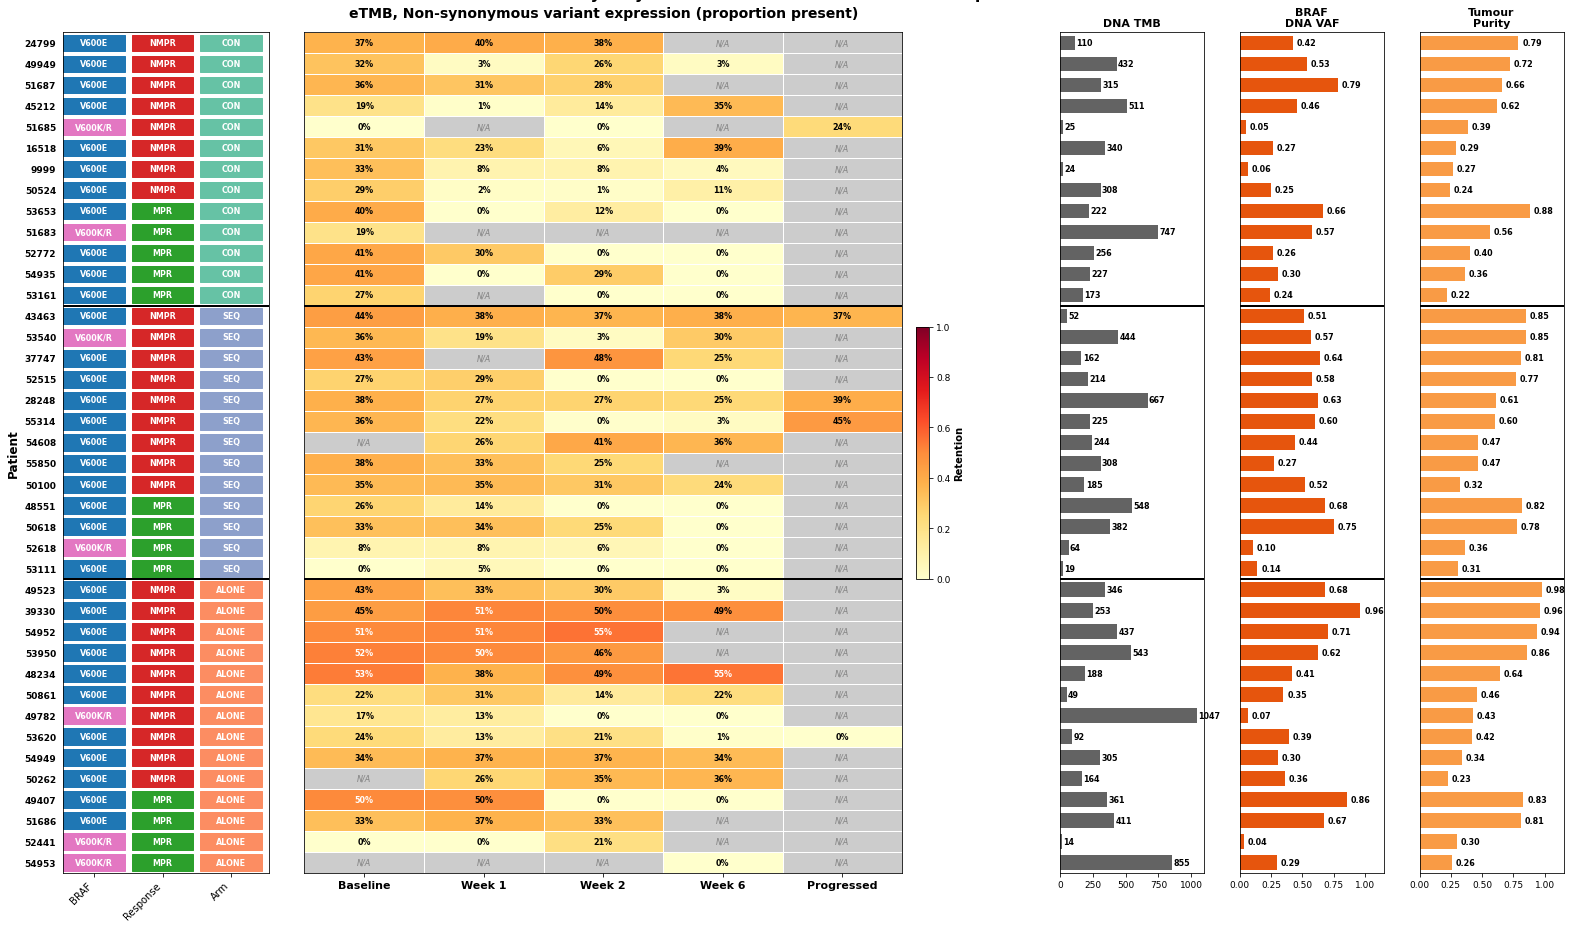

In [67]:
tp_cols = ["Baseline", "Week 1", "Week 2", "Week 6", "Progressed"]

# Sort by treatment arm, response and sort tP
retention_filtered['ARM'] = pd.Categorical(retention_filtered['ARM'], categories=['CON', 'SEQ', 'ALONE'], ordered=True)
retention_filtered['MPR'] = pd.Categorical(retention_filtered['MPR'], categories=['NMPR', 'MPR'], ordered=True)
plot_df = retention_filtered.sort_values(['ARM', 'MPR', 'cellularity'], ascending=[True, True, False]).reset_index(drop=True)

heatmap_data = plot_df[tp_cols].values.astype(float)

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color='#cccccc')

# set dims 
n_patients = len(plot_df)
row_height = 0.25
fig_height = max(10, n_patients * row_height + 3)

fig, axes = plt.subplots(1, 5, figsize=(22, fig_height),
                          gridspec_kw={'width_ratios': [1, 3.5, 0.7, 0.7, 0.7]},
                          sharey=True)

ax_ann = axes[0]
ax_ann.set_xlim(0, 3)
ax_ann.set_ylim(-0.5, n_patients - 0.5)
ax_ann.invert_yaxis()

arm_colors = {'CON': '#66c2a5', 'SEQ': '#8da0cb', 'ALONE': '#fc8d62'}
mpr_colors = {'MPR': '#2ca02c', 'NMPR': '#d62728'}
braf_colors = {'V600E': '#1f77b4', 'V600K/R': '#e377c2'}

for i, row in plot_df.iterrows():
    ax_ann.add_patch(plt.Rectangle((0, i - 0.4), 0.9, 0.8, color=braf_colors.get(row['BRAF_status'], 'grey')))
    ax_ann.text(0.45, i, row['BRAF_status'], ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax_ann.add_patch(plt.Rectangle((1.0, i - 0.4), 0.9, 0.8, color=mpr_colors.get(row['MPR'], 'grey')))
    ax_ann.text(1.45, i, row['MPR'], ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax_ann.add_patch(plt.Rectangle((2.0, i - 0.4), 0.9, 0.8, color=arm_colors.get(row['ARM'], 'grey')))
    ax_ann.text(2.45, i, row['ARM'], ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax_ann.set_xticks([0.45, 1.45, 2.45])
ax_ann.set_xticklabels(['BRAF', 'Response', 'Arm'], fontsize=10, rotation=45, ha='right')
ax_ann.set_yticks(range(n_patients))
ax_ann.set_yticklabels(plot_df['Patient'].astype(str), fontsize=9, fontweight='bold')
ax_ann.tick_params(left=False)
ax_ann.set_ylabel('Patient', fontsize=12, fontweight='bold')

# Arm group separators
prev_arm = None
for i, row in plot_df.iterrows():
    if prev_arm is not None and row['ARM'] != prev_arm:
        for ax in axes:
            ax.axhline(i - 0.5, color='black', linewidth=2)
    prev_arm = row['ARM']

# --- Panel 1: Retention heatmap (eTMB) ---
ax_heat = axes[1]
masked_data = np.ma.masked_invalid(heatmap_data)
im = ax_heat.pcolormesh(np.arange(len(tp_cols) + 1), np.arange(n_patients + 1) - 0.5,
                         masked_data, cmap=cmap, vmin=0, vmax=1, edgecolors='white', linewidth=0.5)

for i in range(n_patients):
    for j in range(len(tp_cols)):
        val = heatmap_data[i, j]
        if np.isnan(val):
            ax_heat.text(j + 0.5, i, 'N/A', ha='center', va='center', fontsize=8, color='grey', style='italic')
        else:
            color = 'white' if val > 0.5 else 'black'
            ax_heat.text(j + 0.5, i, f'{val:.0%}', ha='center', va='center', fontsize=8, color=color, fontweight='bold')

ax_heat.set_xticks(np.arange(len(tp_cols)) + 0.5)
ax_heat.set_xticklabels(tp_cols, fontsize=11, fontweight='bold')
ax_heat.set_title('eTMB, Non-synonymous variant expression (proportion present)', fontsize=14, fontweight='bold', pad=15)
ax_heat.tick_params(left=False)

# --- Panel 2: DNA TMb---
ax_nloci = axes[2]
ax_nloci.barh(range(n_patients), plot_df['n_loci'], color='#636363', height=0.7)
for i, val in enumerate(plot_df['n_loci']):
    ax_nloci.text(val + 10, i, str(val), va='center', fontsize=8, fontweight='bold')
ax_nloci.set_title('DNA TMB', fontsize=11, fontweight='bold')
ax_nloci.tick_params(left=False)
ax_nloci.set_xlabel('')
ax_nloci.tick_params(axis='x', labelsize=9)

# --- Panel 3: BRAF DNA VAF ---
ax_braf = axes[3]
ax_braf.barh(range(n_patients), plot_df['braf_v600_AF'], color='#e6550d', height=0.7)
for i, val in enumerate(plot_df['braf_v600_AF']):
    ax_braf.text(val + 0.03, i, f'{val:.2f}', va='center', fontsize=8, fontweight='bold')
ax_braf.set_xlim(0, 1.15)
ax_braf.set_title('BRAF\nDNA VAF', fontsize=11, fontweight='bold')
ax_braf.tick_params(left=False)
ax_braf.tick_params(axis='x', labelsize=9)

# --- Panel 4: Cellularity ---
ax_cell = axes[4]
ax_cell.barh(range(n_patients), plot_df['cellularity'], color='#f99b45', height=0.7)
for i, val in enumerate(plot_df['cellularity']):
    ax_cell.text(val + 0.03, i, f'{val:.2f}', va='center', fontsize=8, fontweight='bold')
ax_cell.set_xlim(0, 1.15)
ax_cell.set_title('Tumour\nPurity', fontsize=11, fontweight='bold')
ax_cell.tick_params(left=False)
ax_cell.tick_params(axis='x', labelsize=9)

cbar = fig.colorbar(im, ax=axes[1], shrink=0.3, pad=0.02)
cbar.set_label('Retention', fontsize=10, fontweight='bold')
cbar.ax.tick_params(labelsize=9)

plt.suptitle('Nonsynonymous Variant Retention Across Timepoints', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('/scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/cohort_retention_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

In [22]:
### Generate patient specific heatmaps

In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

def build_patient_clustered_heatmap(melpin, syn_coords_df, vcf_cache, output_dir=OUTPUT_DIR):
    patient_loci = syn_coords_df[syn_coords_df['melpin'] == int(melpin)].copy()
    if patient_loci.empty:
        return None

    loci_set = set(zip(patient_loci['Chromosome'], patient_loci['Start_Position']))
    patient_loci['label'] = patient_loci['Hugo_Symbol'] + ' ' + patient_loci['HGVSp_Short'].fillna('')
    loci_to_label = dict(
        zip(zip(patient_loci['Chromosome'], patient_loci['Start_Position']), patient_loci['label'])
    )

    # Build binary matrix
    ordered_loci = sorted(loci_set, key=lambda x: (x[0], x[1]))
    rows = []
    row_labels = []

    for locus in ordered_loci:
        row = []
        for tp in tp_order:
            if (int(melpin), tp) not in vcf_cache:
                row.append(np.nan)
            else:
                parsed = vcf_cache[(int(melpin), tp)]
                val = parsed.get(locus, (0.0, None))[0]
                row.append(1 if val > 0 else 0)
        rows.append(row)
        row_labels.append(loci_to_label.get(locus, f"{locus[0]}:{locus[1]}"))

    df_heat = pd.DataFrame(rows, columns=tp_order, index=row_labels)

    # Drop timepoints that are all NaN (no sample)
    available_tps = [tp for tp in tp_order if not df_heat[tp].isna().all()]
    df_heat = df_heat[available_tps]

    if df_heat.empty or len(df_heat) < 2:
        return None

    # Cluster rows (fill NaN with 0 for clustering only)
    cluster_data = df_heat.fillna(0).values
    if len(cluster_data) > 1:
        try:
            row_linkage = linkage(pdist(cluster_data, metric='hamming'), method='ward')
            row_order = dendrogram(row_linkage, no_plot=True)['leaves']
        except:
            row_order = list(range(len(df_heat)))
    else:
        row_order = [0]

    df_heat = df_heat.iloc[row_order]

    # Plot
    n_loci = len(df_heat)
    fig_height = max(5, n_loci * 0.25 + 3)
    fig_width = max(6, len(available_tps) * 1.2 + 4)

    cmap = ListedColormap(['#f0f0f0', '#d62728'])
    cmap.set_bad(color='#cccccc')

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    masked = np.ma.masked_invalid(df_heat.values.astype(float))
    sns.heatmap(
        df_heat.astype(float),
        cmap=cmap,
        vmin=0, vmax=1,
        linewidths=0.3,
        linecolor='grey',
        cbar=False,
        ax=ax,
        mask=df_heat.isna(),
    )
    # Grey out NaN cells
    for i in range(df_heat.shape[0]):
        for j in range(df_heat.shape[1]):
            if pd.isna(df_heat.iloc[i, j]):
                ax.add_patch(plt.Rectangle((j, i), 1, 1, color='#cccccc'))

    # Get response info
    patient_row = retention_filtered[retention_filtered['Patient'] == int(melpin)]
    mpr_label = patient_row['MPR'].values[0] if len(patient_row) > 0 else ''
    arm_label = patient_row['ARM'].values[0] if len(patient_row) > 0 else ''

    ax.set_title(f"Patient {melpin} | {mpr_label} | {arm_label}\n"
                 f"{n_loci} nonsynonymous variants (clustered)",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Variant', fontsize=10)
    ax.set_xlabel('Timepoint', fontsize=10)
    ax.tick_params(axis='y', labelsize=6 if n_loci > 50 else 8)
    ax.tick_params(axis='x', labelsize=10)

    legend_elements = [
        Patch(facecolor='#d62728', edgecolor='grey', label='Present'),
        Patch(facecolor='#f0f0f0', edgecolor='grey', label='Absent'),
        Patch(facecolor='#cccccc', edgecolor='grey', label='No Sample'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)

    plt.tight_layout()
    out_path = os.path.join(output_dir, f"{melpin}_clustered_heatmap.png")
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved: {out_path} ({n_loci} variants)")
    return df_heat

In [24]:
all_loci = set(zip(syn_coords_df['Chromosome'], syn_coords_df['Start_Position']))
vcf_cache = {}
vcf_paths = sorted(glob.glob(os.path.join(FILTERED_VCF, "*.filtered.vcf")))

for vcf_path in vcf_paths:
    filename = os.path.basename(vcf_path)
    match = re.match(r"^(\d+)(CLND|PROG|PRO|PRE|ED1|ED2)", filename, re.IGNORECASE)
    if match:
        patient_id = int(match.group(1))
        tp_key = match.group(2).upper()
        tp_label = timepoint_map.get(tp_key, "Unknown")
        vcf_cache[(patient_id, tp_label)] = parse_vcf_for_loci(vcf_path, all_loci)

print(f"Cached {len(vcf_cache)} VCFs")

Cached 223 VCFs


In [25]:
# Run for filtered patients only
for melpin in sorted(retention_filtered['Patient'].unique()):
    build_patient_clustered_heatmap(melpin, syn_coords_df, vcf_cache)

Saved: /scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/16518_clustered_heatmap.png (340 variants)
Saved: /scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/24799_clustered_heatmap.png (110 variants)
Saved: /scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/28248_clustered_heatmap.png (667 variants)
Saved: /scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/37747_clustered_heatmap.png (162 variants)
Saved: /scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/39330_clustered_heatmap.png (253 variants)
Saved: /scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/43463_clustered_heatmap.png (52 variants)
Saved: /scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/45212_clustered_heatmap.png (511 variants)
Saved: /scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/48234_clustered_heatmap.png (188 variants)
Saved: /scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/48551_clustered_heatmap.png (548 variants)
Saved: /scratch/jo11/NeoTrio_RNA_variants/non_synonym_he

In [26]:
### Next, what are the variants that are consistently being maintained or excluded with treatment?

In [27]:
def get_variant_status_matrix(syn_coords_df, vcf_cache, retention_filtered):
    """Build a matrix of variant status across all patients at each timepoint."""
    filtered_patients = set(retention_filtered['Patient'].astype(int))
    
    records = []
    for melpin in filtered_patients:
        patient_loci = syn_coords_df[syn_coords_df['melpin'] == int(melpin)].copy()
        if patient_loci.empty:
            continue
        
        patient_loci['label'] = patient_loci['Hugo_Symbol'] + ' ' + patient_loci['HGVSp_Short'].fillna('')
        
        for _, locus_row in patient_loci.iterrows():
            chrom = locus_row['Chromosome']
            pos = locus_row['Start_Position']
            gene = locus_row['Hugo_Symbol']
            label = locus_row['label']
            
            # Get patient metadata
            pmeta = retention_filtered[retention_filtered['Patient'] == int(melpin)]
            mpr = pmeta['MPR'].values[0] if len(pmeta) > 0 else None
            
            for tp in tp_order:
                if (int(melpin), tp) not in vcf_cache:
                    continue
                parsed = vcf_cache[(int(melpin), tp)]
                val = parsed.get((chrom, pos), (0.0, None))[0]
                present = 1 if val > 0 else 0
                
                records.append({
                    'Patient': melpin,
                    'Gene': gene,
                    'Variant': label,
                    'Timepoint': tp,
                    'Present': present,
                    'MPR': mpr,
                })
    
    return pd.DataFrame(records)

variant_status = get_variant_status_matrix(syn_coords_df, vcf_cache, retention_filtered)
print(f"Total records: {len(variant_status)}")
print(variant_status.head())

Total records: 42400
   Patient    Gene         Variant Timepoint  Present   MPR
0    16518  TTLL10  TTLL10 p.P314L  Baseline        0  None
1    16518  TTLL10  TTLL10 p.P314L    Week 1        0  None
2    16518  TTLL10  TTLL10 p.P314L    Week 2        0  None
3    16518  TTLL10  TTLL10 p.P314L    Week 6        0  None
4    16518   DISP3   DISP3 p.V977M  Baseline        0  None


In [28]:
# Merge all timepoints together
baseline = variant_status[variant_status['Timepoint'] == 'Baseline'][['Patient', 'Gene', 'Variant', 'Present', 'MPR']].copy()
week1 = variant_status[variant_status['Timepoint'] == 'Week 1'][['Patient', 'Gene', 'Variant', 'Present']].copy()
week2 = variant_status[variant_status['Timepoint'] == 'Week 2'][['Patient', 'Gene', 'Variant', 'Present']].copy()
week6 = variant_status[variant_status['Timepoint'] == 'Week 6'][['Patient', 'Gene', 'Variant', 'Present']].copy()
progressed = variant_status[variant_status['Timepoint'] == 'Progressed'][['Patient', 'Gene', 'Variant', 'Present']].copy()

paired = baseline.rename(columns={'Present': 'Baseline'})

for tp_df, tp_name in [(week1, 'Week 1'), (week2, 'Week 2'), (week6, 'Week 6'), (progressed, 'Progressed')]:
    paired = paired.merge(
        tp_df.rename(columns={'Present': tp_name}),
        on=['Patient', 'Gene', 'Variant'],
        how='left',
    )

print(f"Total paired records: {len(paired)}")
print(f"Patients: {paired['Patient'].nunique()}")
print(paired.head(10))

Total paired records: 11170
Patients: 37
   Patient      Gene           Variant  Baseline   MPR  Week 1  Week 2  \
0    16518    TTLL10    TTLL10 p.P314L         0  None     0.0     0.0   
1    16518     DISP3     DISP3 p.V977M         0  None     0.0     0.0   
2    16518    LRRC38     LRRC38 p.D41N         0  None     0.0     0.0   
3    16518      UBR4     UBR4 p.K1696R         1  None     1.0     0.0   
4    16518     AHDC1     AHDC1 p.S497F         0  None     0.0     0.0   
5    16518    MAP7D1    MAP7D1 p.E695K         1  None     1.0     0.0   
6    16518     RSPO1       RSPO1 p.R2Q         0  None     0.0     0.0   
7    16518    ERICH3    ERICH3 p.D602N         0  None     0.0     0.0   
8    16518  ARHGAP29  ARHGAP29 p.R758*         1  None     0.0     0.0   
9    16518   COL11A1  COL11A1 p.D1574N         0  None     1.0     1.0   

   Week 6  Progressed  
0     0.0         NaN  
1     0.0         NaN  
2     0.0         NaN  
3     1.0         NaN  
4     1.0         NaN  


In [29]:
gene_patient_counts = paired.groupby('Gene')['Patient'].nunique().reset_index(name='n_patients')
print(f"Total genes: {len(gene_patient_counts)}")
print(f"Genes in ≥3 patients: {len(gene_patient_counts[gene_patient_counts['n_patients'] >= 3])}")
print(f"Genes in ≥2 patients: {len(gene_patient_counts[gene_patient_counts['n_patients'] >= 2])}")
print(f"\nTop 10 most recurrent:")
print(gene_patient_counts.sort_values('n_patients', ascending=False).head(10))

Total genes: 6325
Genes in ≥3 patients: 846
Genes in ≥2 patients: 2142

Top 10 most recurrent:
         Gene  n_patients
600      BRAF          36
5376     TERT          25
3245    MGAM2          19
4541      RP1          16
4007  PKHD1L1          13
3125   MALRD1          12
1502    DNAH7          12
284      ANK3          11
1501    DNAH6          10
163    ADGRV1          10


In [33]:
print(f"paired columns: {paired.columns.tolist()}")
print(f"paired shape: {paired.shape}")



paired columns: ['Patient', 'Gene', 'Variant', 'Baseline', 'MPR', 'Week 1', 'Week 2', 'Week 6', 'Progressed']
paired shape: (11170, 9)


In [34]:
mpr_map_dict = dict(zip(retention_filtered['Patient'].astype(int), retention_filtered['MPR']))
paired['MPR'] = paired['Patient'].map(mpr_map_dict)

print(paired['MPR'].value_counts())

MPR
NMPR    7676
MPR     3494
Name: count, dtype: int64


In [ ]:
## Survival analysis based on eTMB and TMB etc

In [39]:
surv_data = pd.read_csv("/scratch/jo11/NeoTrio_RNA_variants/surv_data_neotrio.csv")
surv_data.columns
clinical= surv_data

In [37]:
sequenza_df.head()

,Unnamed: 0,sample_id,cellularity,ploidy,SLPP,n_solutions,n_segments,pass_purity_20_sequenza,batch,join_key,...,sample_full,maf_number,melpin,maf_file,tmb_count,tmb_per_mbp,braf_v600_AF,purity_est_perc,pass_purity_20perc_th_vaf,melpin_clean
0,0,37747PRE-37747-1,0.81,2.1,0.986397,3,121,PASS,Batch_1,37747PRE-37747-1,...,37747PRE-37747-1_g.hard-filtered,6,37747PRE,6.vep.maf,162,3.24,0.638554,127.710843,Yes,37747
1,1,43306PRE-43306-1,0.10,2.3,0.162976,1,145,FAIL,Batch_1,43306PRE-43306-1,...,43306PRE-43306-1_g.hard-filtered,8,43306PRE,8.vep.maf,488,9.76,0.166667,33.333333,Yes,43306
2,2,47711PRE-47711-1,0.12,1.8,0.149732,3,124,FAIL,Batch_1,47711PRE-47711-1,...,47711PRE-47711-1_g.hard-filtered,13,47711PRE,13.vep.maf,164,3.28,0.175258,35.051546,Yes,47711
3,3,18369PRE-18369-1,0.15,2.0,0.089357,4,104,FAIL,Batch_1,18369PRE-18369-1,...,18369PRE-18369-1_g.hard-filtered,2,18369PRE,2.vep.maf,515,10.30,0.411290,82.258065,Yes,18369
4,4,48234PRE-48234-1,0.64,2.3,0.650946,4,136,PASS,Batch_1,48234PRE-48234-1,...,48234PRE-48234-1_g.hard-filtered,15,48234PRE,15.vep.maf,188,3.76,0.414141,82.828283,Yes,48234


TMB/Mb distribution: median=5.1, range=0.3-20.9
TMB_group
Low TMB (<10)     33
High TMB (≥10)     7
Name: count, dtype: int64



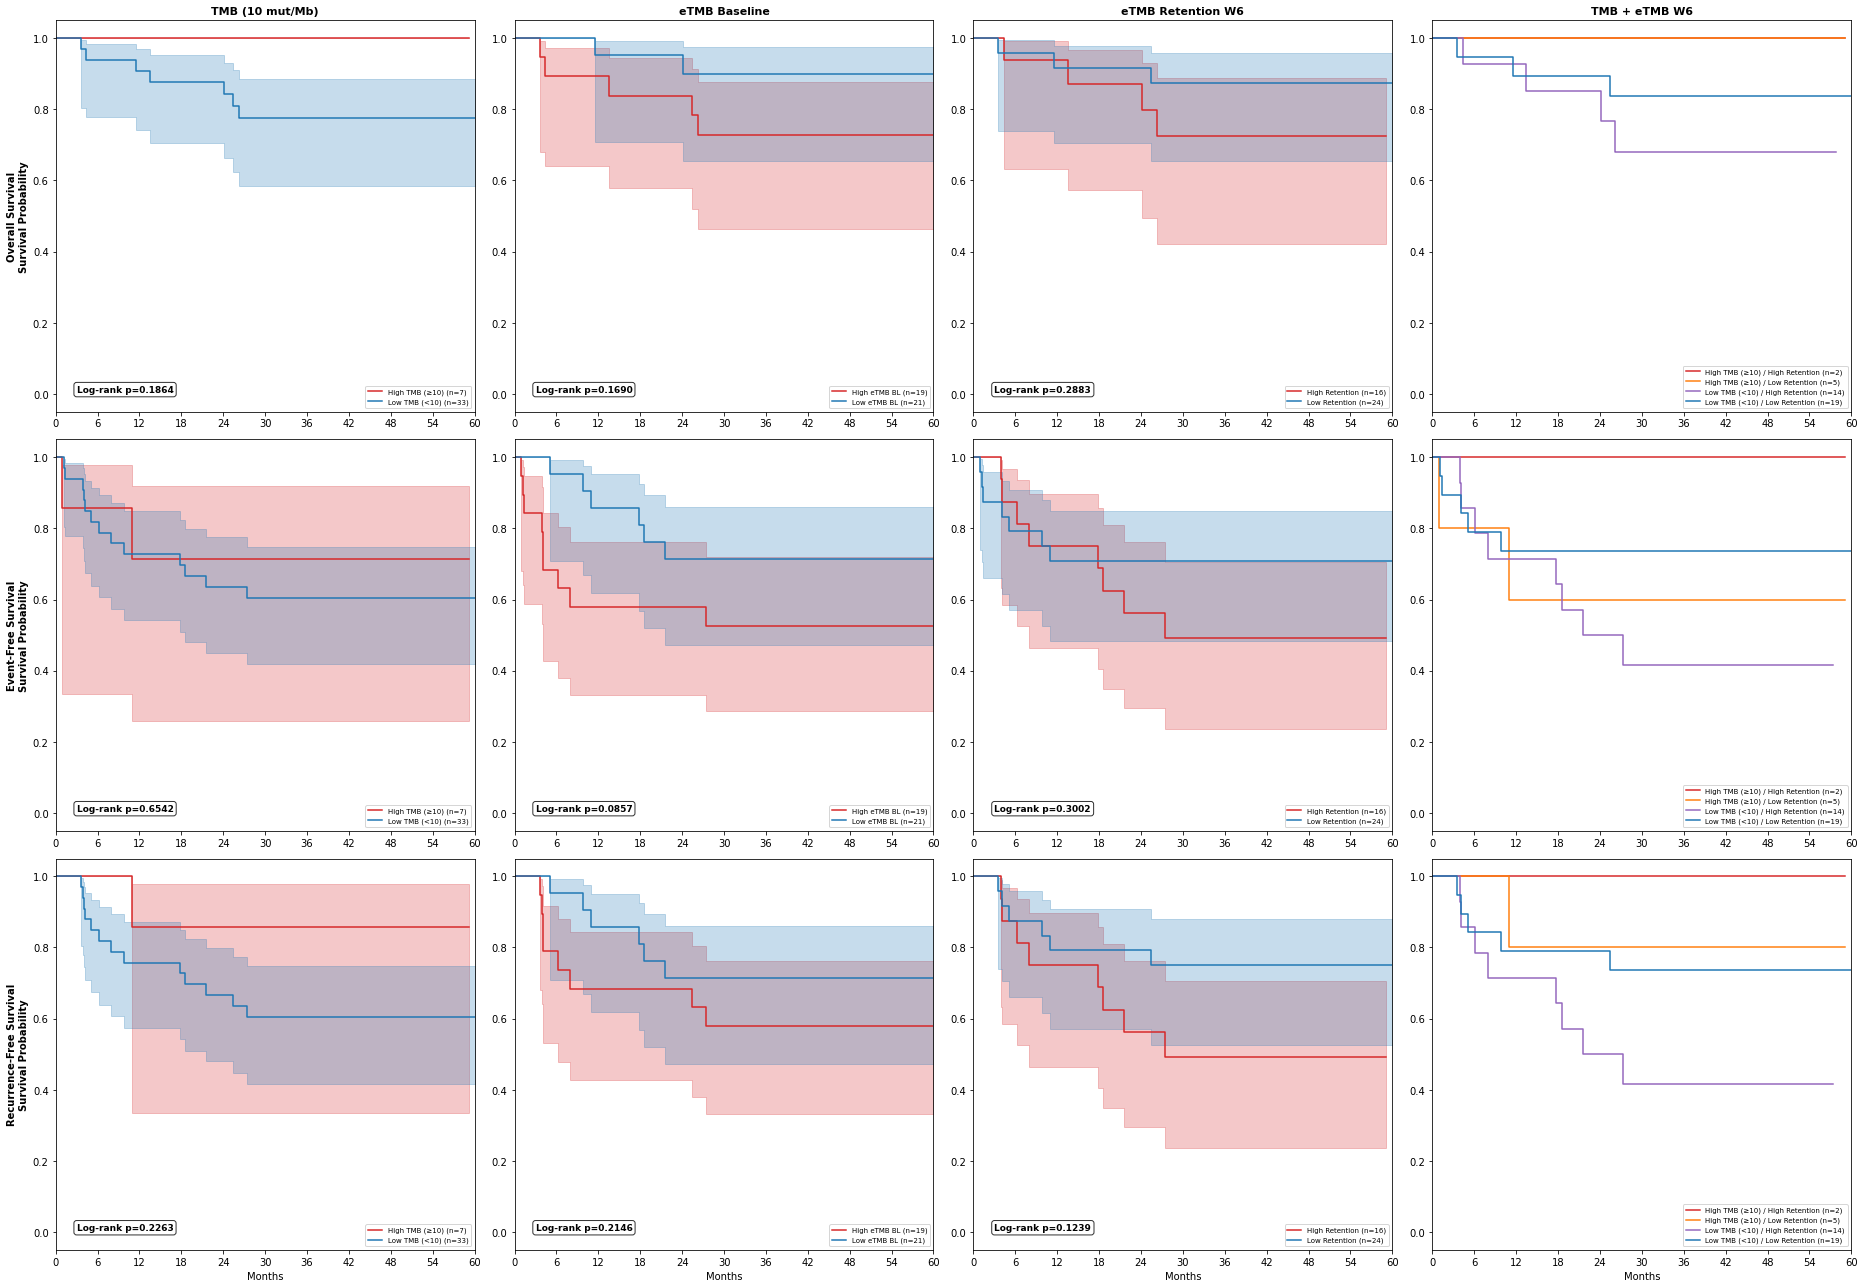


Endpoint                       Model                     Variable              HR                 95% CI          p    C-index
Overall Survival               TMB univariate            TMB_per_mb          0.78 (0.61-1.01)            0.0628       0.73
Overall Survival               eTMB BL univariate        Baseline           31.24 (0.02-41697.37)            0.3486       0.67
Overall Survival               eTMB W6 univariate        Week 6           9351.04 (2.63-33271946.93)            0.0284       0.85
Overall Survival               TMB + eTMB W6             TMB_per_mb          0.64 (0.38-1.07)            0.0890       0.91
Overall Survival               TMB + eTMB W6             Week 6          23827.67 (2.15-264488742.67)            0.0339       0.91
Overall Survival               TMB + eTMB BL             TMB_per_mb          0.69 (0.49-0.96)            0.0297       0.74
Overall Survival               TMB + eTMB BL             Baseline          452.28 (0.35-583625.77)            0.094

In [48]:

# Merge clinical with TMB/eTMB data
plot_df['melpin'] = plot_df['Patient'].astype(str)
clinical['melpin'] = clinical['melpin'].astype(str)

surv = plot_df.merge(clinical, on='melpin', how='inner')

surv['date_neoadj_start'] = pd.to_datetime(surv['date_neoadj_start'], dayfirst=True)

endpoints = {
    'Overall Survival': ('survival_status', 'survival_date'),
    'Event-Free Survival': ('event_status', 'eventfree_date'),
    'Recurrence-Free Survival': ('recurrence_status', 'recurrencefree_date'),
}

for ep_name, (status_col, date_col) in endpoints.items():
    surv[date_col] = pd.to_datetime(surv[date_col], dayfirst=True)
    surv[f'{ep_name}_months'] = (surv[date_col] - surv['date_neoadj_start']).dt.days / 30.44

# TMB per Mb (50 Mb capture)
capture_size_mb = 50
surv['TMB_per_mb'] = surv['n_loci'] / capture_size_mb

# Clinical cutoff: 10 mut/Mb
surv['TMB_group'] = np.where(surv['TMB_per_mb'] >= 10, 'High TMB (≥10)', 'Low TMB (<10)')

print(f"TMB/Mb distribution: median={surv['TMB_per_mb'].median():.1f}, "
      f"range={surv['TMB_per_mb'].min():.1f}-{surv['TMB_per_mb'].max():.1f}")
print(surv['TMB_group'].value_counts())
print()

etmb_w6_median = surv['Week 6'].dropna().median()
surv['eTMB_W6_group'] = np.where(surv['Week 6'] >= etmb_w6_median, 'High Retention', 'Low Retention')

etmb_bl_median = surv['Baseline'].dropna().median()
surv['eTMB_BL_group'] = np.where(surv['Baseline'] >= etmb_bl_median, 'High eTMB BL', 'Low eTMB BL')

# Combined groups
surv['TMB_eTMB_W6'] = surv['TMB_group'] + ' / ' + surv['eTMB_W6_group']
surv['TMB_eTMB_BL'] = surv['TMB_group'] + ' / ' + surv['eTMB_BL_group']

# ---- KM PLOTS ----
fig, axes = plt.subplots(3, 4, figsize=(26, 18))

km_configs = [
    ('TMB_group', {'High TMB (≥10)': '#d62728', 'Low TMB (<10)': '#1f77b4'}, 'TMB (10 mut/Mb)'),
    ('eTMB_BL_group', {'High eTMB BL': '#d62728', 'Low eTMB BL': '#1f77b4'}, 'eTMB Baseline'),
    ('eTMB_W6_group', {'High Retention': '#d62728', 'Low Retention': '#1f77b4'}, 'eTMB Retention W6'),
    ('TMB_eTMB_W6', {
        'High TMB (≥10) / High Retention': '#d62728',
        'High TMB (≥10) / Low Retention': '#ff7f0e',
        'Low TMB (<10) / High Retention': '#9467bd',
        'Low TMB (<10) / Low Retention': '#1f77b4',
    }, 'TMB + eTMB W6'),
]

for row, (ep_name, (status_col, date_col)) in enumerate(endpoints.items()):
    time_col = f'{ep_name}_months'
    
    for col, (group_col, colors, title_suffix) in enumerate(km_configs):
        ax = axes[row, col]
        ep_df = surv.dropna(subset=[time_col, status_col]).copy()
        ep_df[status_col] = ep_df[status_col].astype(int)
        
        kmf = KaplanMeierFitter()
        groups = sorted(ep_df[group_col].dropna().unique())
        ci_show = len(colors) <= 2
        
        for grp in groups:
            mask = ep_df[group_col] == grp
            if mask.sum() >= 2:
                kmf.fit(ep_df.loc[mask, time_col], ep_df.loc[mask, status_col],
                        label=f'{grp} (n={mask.sum()})')
                kmf.plot_survival_function(ax=ax, color=colors.get(grp, 'grey'), ci_show=ci_show)
        
        # Log-rank for 2-group comparisons
        if len(colors) == 2:
            g1, g2 = list(colors.keys())
            s1 = ep_df[ep_df[group_col] == g1]
            s2 = ep_df[ep_df[group_col] == g2]
            if len(s1) >= 2 and len(s2) >= 2:
                lr = logrank_test(s1[time_col], s2[time_col], s1[status_col], s2[status_col])
                ax.text(0.05, 0.05, f'Log-rank p={lr.p_value:.4f}',
                        transform=ax.transAxes, fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        if row == 0:
            ax.set_title(title_suffix, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{ep_name}\nSurvival Probability', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel('')
        ax.set_xlabel('Months' if row == 2 else '')
        ax.legend(fontsize=7, loc='lower right')
        ax.set_ylim(-0.05, 1.05)
        
        # 6-month intervals
        max_time = ep_df[time_col].max()
        ax.set_xlim(0, 60)
        ax.set_xticks(np.arange(0, 66, 6))

plt.suptitle('Survival Analysis: TMB and eTMB Retention', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/survival_TMB_eTMB.png',
            dpi=200, bbox_inches='tight')
plt.show()

# ---- Cox PH Summary Table ----
print("\n" + "="*200)
print(f"{'Endpoint':<30} {'Model':<25} {'Variable':<15} {'HR':>8} {'95% CI':>22} {'p':>10} {'C-index':>10}")
print("="*200)

cox_models = [
    ('TMB univariate', ['TMB_per_mb']),
    ('eTMB BL univariate', ['Baseline']),
    ('eTMB W6 univariate', ['Week 6']),
    ('TMB + eTMB W6', ['TMB_per_mb', 'Week 6']),
    ('TMB + eTMB BL', ['TMB_per_mb', 'Baseline']),
    ('TMB + eTMB BL + W6', ['TMB_per_mb', 'Baseline', 'Week 6']),
]

for ep_name, (status_col, date_col) in endpoints.items():
    time_col = f'{ep_name}_months'
    
    for model_name, covariates in cox_models:
        ep_df = surv.dropna(subset=[time_col, status_col] + covariates).copy()
        ep_df[status_col] = ep_df[status_col].astype(int)
        
        if len(ep_df) < 10:
            continue
        
        try:
            cph = CoxPHFitter()
            cph.fit(ep_df[[time_col, status_col] + covariates],
                    duration_col=time_col, event_col=status_col)
            
            for var in covariates:
                hr = cph.hazard_ratios_[var]
                ci = cph.confidence_intervals_.loc[var]
                p_val = cph.summary.loc[var, 'p']
                c_idx = cph.concordance_index_
                
                print(f"{ep_name:<30} {model_name:<25} {var:<15} {hr:>8.2f} "
                      f"({np.exp(ci.iloc[0]):>.2f}-{np.exp(ci.iloc[1]):>.2f}){'':<7} "
                      f"{p_val:>10.4f} {c_idx:>10.2f}")
        except Exception as e:
            print(f"{ep_name:<30} {model_name:<25} FAILED: {e}")
    
    print("-"*200)

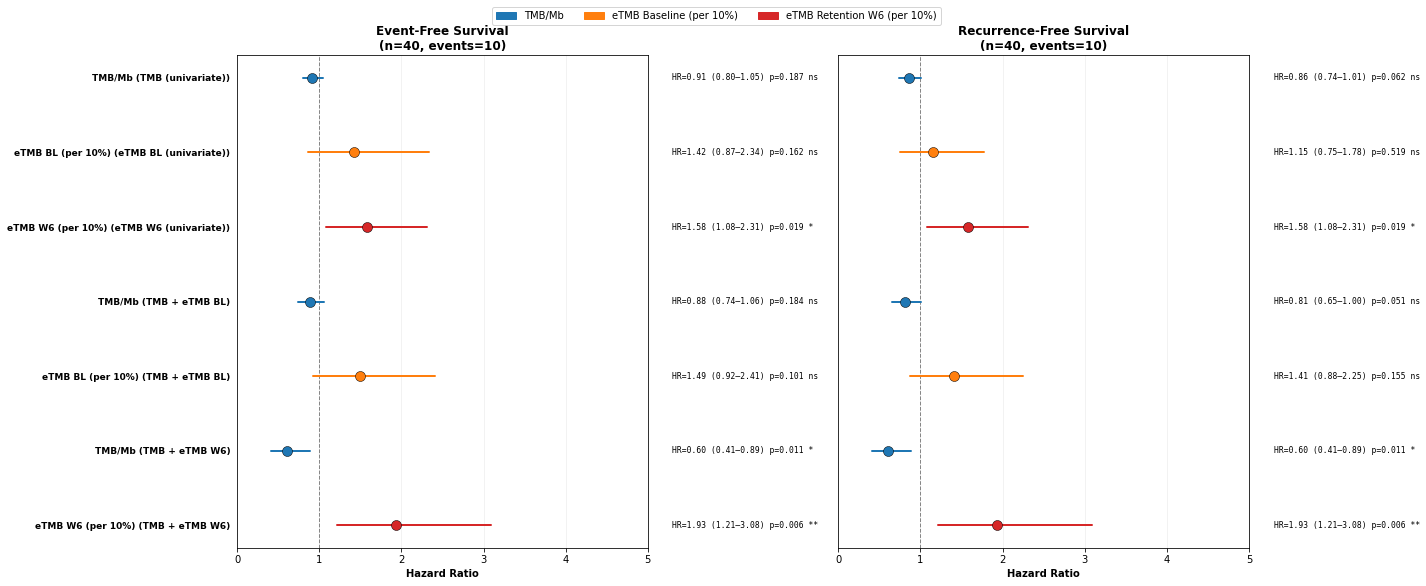

In [66]:
import matplotlib.patches as mpatches

forest_data = []
surv['Week 6_pct'] = surv['Week 6'] * 10
surv['Baseline_pct'] = surv['Baseline'] * 10

cox_models = [
    ('TMB (univariate)', ['TMB_per_mb']),
    ('eTMB BL (univariate)', ['Baseline_pct']),
    ('eTMB W6 (univariate)', ['Week 6_pct']),
    ('TMB + eTMB BL', ['TMB_per_mb', 'Baseline_pct']),
    ('TMB + eTMB W6', ['TMB_per_mb', 'Week 6_pct']),
]

for ep_name, (status_col, date_col) in endpoints.items():
    time_col = f'{ep_name}_months'
    
    for model_name, covariates in cox_models:
        ep_df = surv.dropna(subset=[time_col, status_col] + covariates).copy()
        ep_df[status_col] = ep_df[status_col].astype(int)
        
        try:
            cph = CoxPHFitter()
            cph.fit(ep_df[[time_col, status_col] + covariates],
                    duration_col=time_col, event_col=status_col)
            
            for var in covariates:
                hr = cph.hazard_ratios_[var]
                ci = cph.confidence_intervals_.loc[var]
                ci_lo = np.exp(ci.iloc[0])
                ci_hi = np.exp(ci.iloc[1])
                p_val = cph.summary.loc[var, 'p']
                c_idx = cph.concordance_index_
                n_events = ep_df[status_col].sum()
                
                if var == 'TMB_per_mb':
                    var_label = 'TMB/Mb'
                elif var == 'Baseline_pct':
                    var_label = 'eTMB BL (per 10%)'
                else:
                    var_label = 'eTMB W6 (per 10%)'
                
                forest_data.append({
                    'endpoint': ep_name,
                    'model': model_name,
                    'variable': var_label,
                    'label': f'{var_label} ({model_name})',
                    'hr': hr,
                    'ci_lo': ci_lo,
                    'ci_hi': ci_hi,
                    'p': p_val,
                    'c_index': c_idx,
                    'n_events': int(n_events),
                })
        except:
            pass

fdf = pd.DataFrame(forest_data)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

ep_order = ['Event-Free Survival', 'Recurrence-Free Survival']
var_colors = {'TMB/Mb': '#1f77b4', 'eTMB BL (per 10%)': '#ff7f0e', 'eTMB W6 (per 10%)': '#d62728'}

for ax, ep_name in zip(axes, ep_order):
    ep = fdf[fdf['endpoint'] == ep_name].copy()
    ep = ep.iloc[::-1].reset_index(drop=True)
    
    n_rows = len(ep)
    
    for i, row in ep.iterrows():
        color = var_colors[row['variable']]
        
        ci_lo_plot = max(row['ci_lo'], 0.05)
        ci_hi_plot = min(row['ci_hi'], 5)
        
        ax.plot([ci_lo_plot, ci_hi_plot], [i, i], color=color, linewidth=2, solid_capstyle='round')
        ax.plot(row['hr'], i, 'o', color=color, markersize=10, markeredgecolor='black', markeredgewidth=0.5)
        
        if row['p'] < 0.001:
            sig = '***'
        elif row['p'] < 0.01:
            sig = '**'
        elif row['p'] < 0.05:
            sig = '*'
        else:
            sig = 'ns'
        
        annot = f"HR={row['hr']:.2f} ({row['ci_lo']:.2f}–{row['ci_hi']:.2f}) p={row['p']:.3f} {sig}"
        if row['ci_hi'] > 5:
            annot = f"HR={row['hr']:.2f} (CI >5) p={row['p']:.3f} {sig}"
        
        ax.text(5.3, i, annot, va='center', fontsize=8, fontfamily='monospace')
    
    ax.axvline(1, color='grey', linestyle='--', linewidth=1, zorder=0)
    ax.set_xlim(0, 5)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(ep['label'], fontsize=9, fontweight='bold')
    ax.set_xlabel('Hazard Ratio', fontsize=10, fontweight='bold')
    
    n_events = ep['n_events'].iloc[0]
    ax.set_title(f'{ep_name}\n(n={len(surv)}, events={n_events})', fontsize=12, fontweight='bold')
    
    ax.grid(axis='x', alpha=0.2)
    ax.tick_params(axis='y', left=False)

legend_elements = [
    mpatches.Patch(color='#1f77b4', label='TMB/Mb'),
    mpatches.Patch(color='#ff7f0e', label='eTMB Baseline (per 10%)'),
    mpatches.Patch(color='#d62728', label='eTMB Retention W6 (per 10%)'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=10,
           frameon=True, bbox_to_anchor=(0.5, 1.02))

plt.suptitle('Cox Proportional Hazards: TMB vs eTMB Retention',
             fontsize=14, fontweight='bold', y=1.08)
plt.tight_layout()
plt.savefig('/scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/forest_plot_TMB_eTMB.png',
            dpi=200, bbox_inches='tight')
plt.show()